In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from augur.utils import json_to_tree
from Bio import Phylo, SeqIO
from collections import Counter

import baltic as bt

## Figure 4: genotype of circulating human virus impacts available HA1 adaptive mutations


In [2]:
def trees_to_baltic(virus):

    nextstrainPath= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    json_translation={'absoluteTime':lambda k: k.traits['node_attrs']['num_date']['value'],
                      'name':'name'}
    tree, metadata = bt.loadJSON(nextstrainPath,json_translation=json_translation)
    
    return tree

In [3]:
def get_strains_w_egg_muts(virus, segment, gene, egg_mut):
    """
    Return the strains with a the given egg mut 
    """
    
    # get muts for each strain
    curated_mut_file = f"../egg-mutation-analysis/egg-muts-by-strain/{virus}_{segment}_curated-egg-muts.json"
    
    with open(curated_mut_file) as json_handle:
        egg_mut_info = json.load(json_handle)
        
    muts_by_strain = {}
        
    for strain, muts in egg_mut_info.items():
        muts_by_strain[strain] = muts.get(gene, [])
    
    strains_w_egg_mut = []

    for s, ms in muts_by_strain.items():
        if egg_mut in ms:
            strains_w_egg_mut.append(s)
                
    return strains_w_egg_mut

In [4]:
# pre run `get_strains_w_egg_muts`
# to speed up plotting

prerun_strains_w_mut = {'h3n2': {}, 'h1n1pdm': {}, 'vic': {}}

In [5]:
h3n2_egg_muts = ['186N', '186S', '186V', '194P', '194I', '225N', '225G', '226I', '195Y', '160K', '160I', '193R']

for m in h3n2_egg_muts:
    prerun_strains_w_mut['h3n2'][m] = get_strains_w_egg_muts('h3n2', 'ha', 'HA1', m)

In [6]:
h1n1pdm_egg_muts = ['187V', '191I', '127E']

for m in h1n1pdm_egg_muts:
    prerun_strains_w_mut['h1n1pdm'][m] = get_strains_w_egg_muts('h1n1pdm', 'ha', 'HA1', m)

In [7]:
vic_egg_muts = ['196S', '196D', '196K', '196T']

for m in vic_egg_muts:
    prerun_strains_w_mut['vic'][m] = get_strains_w_egg_muts('vic', 'ha', 'HA1', m)

In [8]:
def get_branch_aa(virus, segment, gene, site):
    """
    get AA at "site" for every branch in tree
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_{segment}_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    root = tree_json['root_sequence']
    # get the root AA at this site
    root_aa_site = root[gene][site-1]
    
    # apply any muts to root
    root_muts = tree.root.branch_attrs['mutations'].get('HA1', '')
    for m in root_muts:
        if int(m[1:-1]) == site:
            root_aa_site = m[-1]
    
    # record all muts at this site by what branch they occur on
    muts_at_site = {}
    
    for node in tree.find_clades():
        ha1_muts = node.branch_attrs['mutations'].get('HA1', '')
        ha1_mut_sites = [int(x[1:-1]) for x in ha1_muts]
        if site in ha1_mut_sites:
            for y in ha1_muts:
                if int(y[1:-1])==site:
                    muts_at_site[node.name] = y
                    
    # record the AA genotype at this site for each node
    aa_at_node = {}

    for node in tree.find_clades():
        # get path to root
        path_to_root = [x.name for x in tree.get_path(node)]
        muts_on_path = [muts_at_site.get(n, '') for n in path_to_root]
        # get most recent mut
        last_mut = next((x for x in reversed(muts_on_path) if x != ''), '')
        if last_mut=='':
            site_aa = root_aa_site
        else:
            site_aa = last_mut[-1]

        aa_at_node[node.name] = site_aa
        
    return aa_at_node

In [9]:
# pre run `get_branch_aa(virus, segment, gene, site)`
# to speed up plotting

prerun_aa_at_node = {'h3n2': {}, 'h1n1pdm': {}, 'vic': {}}

In [10]:
h3n2_sites = [186, 160, 155, 193, 195, 225, 226]

for s in h3n2_sites:
    prerun_aa_at_node['h3n2'][s] = get_branch_aa('h3n2', 'ha', 'HA1', s)

In [11]:
h1n1pdm_sites = [130,183]

for s in h1n1pdm_sites:
    prerun_aa_at_node['h1n1pdm'][s] = get_branch_aa('h1n1pdm', 'ha', 'HA1', s)

In [12]:
vic_sites = [196]

for s in vic_sites:
    prerun_aa_at_node['vic'][s] = get_branch_aa('vic', 'ha', 'HA1', s)

In [13]:
color_list = ['#FD3855', '#fb8500', '#9C3587', '#00b4d8', 
              '#bd021e', '#fbc400', '#d585c5', '#0077b6', 
              '#7be7ff', '#fe99a8', '#612154']


In [14]:
def plot_tree(virus, segment, gene, egg_muts, site, ax):
    """
    Draw the tree for each virus using baltic
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'

    branchWidth=0.5
    verticalWidth=0.75

    
    tree = trees_to_baltic(virus)
    
    # for each egg mut, find all egg-passaged strains that have it
    egg_mut_by_strain = {}
    # list of all tips with at least one of these egg muts 
    all_strains_w_egg_mut = []
    for egg_mut in egg_muts:
        if egg_mut in prerun_aa_at_node[virus].keys():
            strains_w_egg_mut = prerun_aa_at_node[virus][egg_mut]
        else:
            strains_w_egg_mut = get_strains_w_egg_muts(virus, segment, gene, egg_mut)
            
        egg_mut_by_strain[egg_mut] = strains_w_egg_mut
        all_strains_w_egg_mut+=strains_w_egg_mut
        
    # color for each egg_mut
    tips_cmap = [{'tip_color': '#00c88a', 'edge_color': '#008d61'}, 
                 {'tip_color': '#006e5e', 'edge_color': '#00473c'}, 
                 {'tip_color': '#9ee79e', 'edge_color': '#6edc6e'},
                 {'tip_color': '#006646', 'edge_color': '#002b1e'}]
    # allow manual color for some to make them more visible
    if egg_muts == ['127E']:
        tips_cmap = [{'tip_color': '#006e5e', 'edge_color': '#00473c'}]

    egg_cmap = {e:tips_cmap[i] for i,e in enumerate(egg_muts)}
    
    # get the AA for each branch at the specified site

    if site in prerun_aa_at_node[virus].keys():
        aa_at_node = prerun_aa_at_node[virus][site]
    else:
        aa_at_node = get_branch_aa(virus, segment, gene,  site)
        
    # assign a color to each AA
#     unique_aas = list(set(aa_at_node.values()))
#     aa_cmap = {aa:color_list[i] for i, aa in enumerate(unique_aas)} 
    # only need to include colors for the most common aas (won't be able to see others anyways)
    predominant_aas = [k for k,v in Counter(aa_at_node.values()).items() if v>=100]
    # manual exclude of certain genotypes (egg mut genotypes where it is going to be coloring terminal branch)
    if virus == 'vic' and site == 196:
        predominant_aas = [x for x in predominant_aas if x not in ['S', 'K']]
    elif virus == 'h3n2' and site == 186:
        predominant_aas = [x for x in predominant_aas if x not in ['V']]
    predominant_aas_cmap = {aa:color_list[i] for i, aa in enumerate(predominant_aas)}
    # all other aas will be grey
    all_amino_acids = list("ACDEFGHIKLMNPQRSTVWY-")
    for a in all_amino_acids:
        if a not in predominant_aas_cmap.keys():
            predominant_aas_cmap[a] = '#808080'
    
    


    # k objects are tips, nodes, branches
    for k in tree.Objects: ## iterate over objects in tree
        y=k.y ## or use absolute time instead
        x=k.absoluteTime
        node_name = k.name
        
        aa_at_site = aa_at_node[node_name]
        node_color = predominant_aas_cmap[aa_at_site]


        if x==None: ## matplotlib won't plot Nones, like root
            x=0.0
        if 'node_attrs' in k.parent.traits:
            xp=k.parent.absoluteTime ## get x position of current object's parent
        else:
            xp = x

        if isinstance(k,bt.leaf) or k.branchType=='leaf': ## if leaf...
            m = "."
            if node_name in all_strains_w_egg_mut:
                for em, s in egg_mut_by_strain.items():
                    if node_name in s:
                        tipSize= 30
                        ## plot circle for every tip with this egg mut
                        ax.scatter(x,y, s=tipSize, facecolor=egg_cmap[em]['tip_color'], 
                                   edgecolor=egg_cmap[em]['edge_color'], 
                                   linewidth=0.5, marker=m, zorder=3) 

        
        #plot the vertical lines
        elif isinstance(k,bt.node) or k.branchType=='node': ## if node...
            ax.plot([x,x],[k.children[-1].y, k.children[0].y], lw=verticalWidth, 
                    color=predominant_aas_cmap[aa_at_node[k.children[-1].name]], ls='-',alpha=0.1,zorder=1) 
        
        #plot the branches
        ax.plot([xp,x],[y,y],lw=branchWidth,color=node_color,ls='-',alpha=0.5,zorder=1)


    ax.spines['left'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.tick_params(axis='x', labelsize=10)
    ax.set_yticks([])
    if virus=='h1n1pdm':
        ax.set_xticks([2009,2024])
    elif virus in ['h3n2', 'vic', 'yam']:
        ax.set_xticks([1994, 2009, 2024])
        
    # create legend entries
    egg_mut_legend_entries = [Line2D([0], [0], linestyle= 'None', marker = 'o', markerfacecolor=colors['tip_color'], 
                                     markeredgecolor=colors['edge_color'], markersize=8, label=em) 
                              for em, colors in egg_cmap.items()]

    background_entries = [Line2D([0], [0], color=color, lw=2, label=aa) 
                          for aa, color in predominant_aas_cmap.items() if color != '#808080']
    
    y_start = {'h3n2': 0.75, 'h1n1pdm': 0.7, 'vic': 0.75}
    num_cols = {1:1, 2:1, 3:1, 4:2, 5:2, 6:2, 7:3, 8:3, 9:3}
    
    # plot legend
    legend1 = ax.legend(handles=egg_mut_legend_entries, title="Egg mut", loc='upper left', 
                        fontsize=8, title_fontsize=8, bbox_to_anchor=(-0.02, y_start[virus]), 
                        frameon=False, ncol=num_cols[len(egg_mut_legend_entries)], 
                        handletextpad=0.5, columnspacing=0.5)
    
    # place second legend
    if len(egg_muts)==1:
        legend2 = ax.legend(handles=background_entries, title=f"Genotype at {site}", loc='upper left',
                            fontsize=8, title_fontsize=8, bbox_to_anchor=(-0.02, y_start[virus]-0.2), 
                            frameon=False, ncol=num_cols[len(background_entries)], 
                            handletextpad=0.5, columnspacing=0.5)
    elif len(egg_muts)==2 or len(egg_muts)==4:
        legend2 = ax.legend(handles=background_entries, title=f"Genotype at {site}", loc='upper left',
                        fontsize=8, title_fontsize=8, bbox_to_anchor=(-0.02, y_start[virus]-0.3), 
                            frameon=False, ncol=num_cols[len(background_entries)], 
                            handletextpad=0.5, columnspacing=0.5)
    elif len(egg_muts)==3:
        legend2 = ax.legend(handles=background_entries, title=f"Genotype at {site}", loc='upper left',
                        fontsize=8, title_fontsize=8, bbox_to_anchor=(-0.02, y_start[virus]-0.4), 
                            frameon=False, ncol=num_cols[len(background_entries)], 
                            handletextpad=0.5, columnspacing=0.5)

    # Add the legends to the plot
    ax.add_artist(legend1) 
    
    # align them to the left instead of center
    legend1._legend_box.align = "left"
    legend2._legend_box.align = "left"
    
    # label the virus
    prettify_name = {'h3n2': 'A/H3N2', 'h1n1pdm': 'A/H1N1pdm', 'vic': 'B/Vic', 'yam': 'B/Yam'}
    ypos_text = {'h3n2': 0.5, 'h1n1pdm': 0.45, 'vic': 0.6, 'yam': 0.6}
    ax.text(1.1, ypos_text[virus], f'{prettify_name[virus]}', fontsize=12, rotation=90, ha='right', transform=ax.transAxes)
    

    return ax



In [1]:
def plot_fig4(filename=None):
    """
    For  egg muts that have a temporal aspect, plot location of egg mutations on the phylogeny
    And color branches by genotype in circulating virus that correlates with occurrence of this mut
    """
    
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    fig = plt.figure(figsize=(10, 14))
    # plot heatmap of all muts on left and then freqencies of specific muts on right
    # add row for blank space between viruses
    gs = GridSpec(8, 3, height_ratios=[0.25, 1,1, 0.25,1, 0.25,1,1])
    
    # start with muts that depend on background because of own codon 
    # due to disfavorable AA there
    ax_disfavor_title = fig.add_subplot(gs[0, 0])
    ax_disfavor_title.text(0, 0, 'A', 
                           fontsize=20, transform=ax_disfavor_title.transAxes)
    ax_disfavor_title.text(0, 0, '     Human genotype selected against in eggs', 
                           fontsize=14, transform=ax_disfavor_title.transAxes)
    ax_disfavor_title.axis('off')
    
    ax186 = fig.add_subplot(gs[1, 0])
    plot_tree('h3n2', 'ha', 'HA1',  ['186V', '186N'], 186, ax186)
    
    ax225 = fig.add_subplot(gs[1, 1])
    plot_tree('h3n2', 'ha', 'HA1', ['225N', '225G'], 225, ax225)
    
    ax226 = fig.add_subplot(gs[1, 2])
    plot_tree('h3n2', 'ha', 'HA1', ['226I'], 226, ax226)
    
    ax195 = fig.add_subplot(gs[2, 0])
    plot_tree('h3n2', 'ha', 'HA1', ['195Y'], 195, ax195)
    
    ax160 = fig.add_subplot(gs[2, 1])
    plot_tree('h3n2', 'ha', 'HA1',  ['160K', '160I'], 160, ax160)
    
    ax196 = fig.add_subplot(gs[2, 2])
    plot_tree('vic', 'ha', 'HA1', ['196S', '196D', '196K', '196T'], 196, ax196)
    
    
    # or due to mutational accessibility
    ax_access_title = fig.add_subplot(gs[3, 0])
    ax_access_title.text(0, 0, 'B', 
                           fontsize=20, transform=ax_access_title.transAxes)
    ax_access_title.text(0, 0, '     Mutational accessibility', 
                           fontsize=14, transform=ax_access_title.transAxes)
    ax_access_title.axis('off')
    
    ax193 = fig.add_subplot(gs[4, 0])
    plot_tree('h3n2', 'ha', 'HA1',  ['193R'], 193, ax193)
    
    
    # then muts that depend on background because of epistasis
    ax_epi_title = fig.add_subplot(gs[5, 0])
    ax_epi_title.text(0, 0, 'C', 
                           fontsize=20, transform=ax_epi_title.transAxes)
    ax_epi_title.text(0, 0, '     Epistasis', 
                           fontsize=14, transform=ax_epi_title.transAxes)
    ax_epi_title.axis('off')
    
    ax193 = fig.add_subplot(gs[6, 0])
    plot_tree('h3n2', 'ha', 'HA1', ['194P'], 193, ax193)
    
    ax155 = fig.add_subplot(gs[7, 0])
    plot_tree('h3n2', 'ha', 'HA1', ['194I'], 155, ax155)
    
    ax130 = fig.add_subplot(gs[7, 1])
    plot_tree('h1n1pdm', 'ha', 'HA1', ['127E'], 130, ax130)
    
    ax183 = fig.add_subplot(gs[7, 2])
    plot_tree('h1n1pdm', 'ha', 'HA1', ['187V', '191I'], 183, ax183)
    
    if filename:
        fig.savefig(filename, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')



Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)


Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)


Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)


Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)


Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)


Tree height: 36.253000
Tree length: 6819.050000
annotations present

Numbers of objects in tree: 21957 (10259 nodes and 11698 leaves)


Tree height: 32.022000
Tree length: 4105.366000
annotations present

Numbers of objects in tree: 21904 (10457 nodes and 11447 leaves)


Tree height: 32.022000
Tree length: 4105.366000

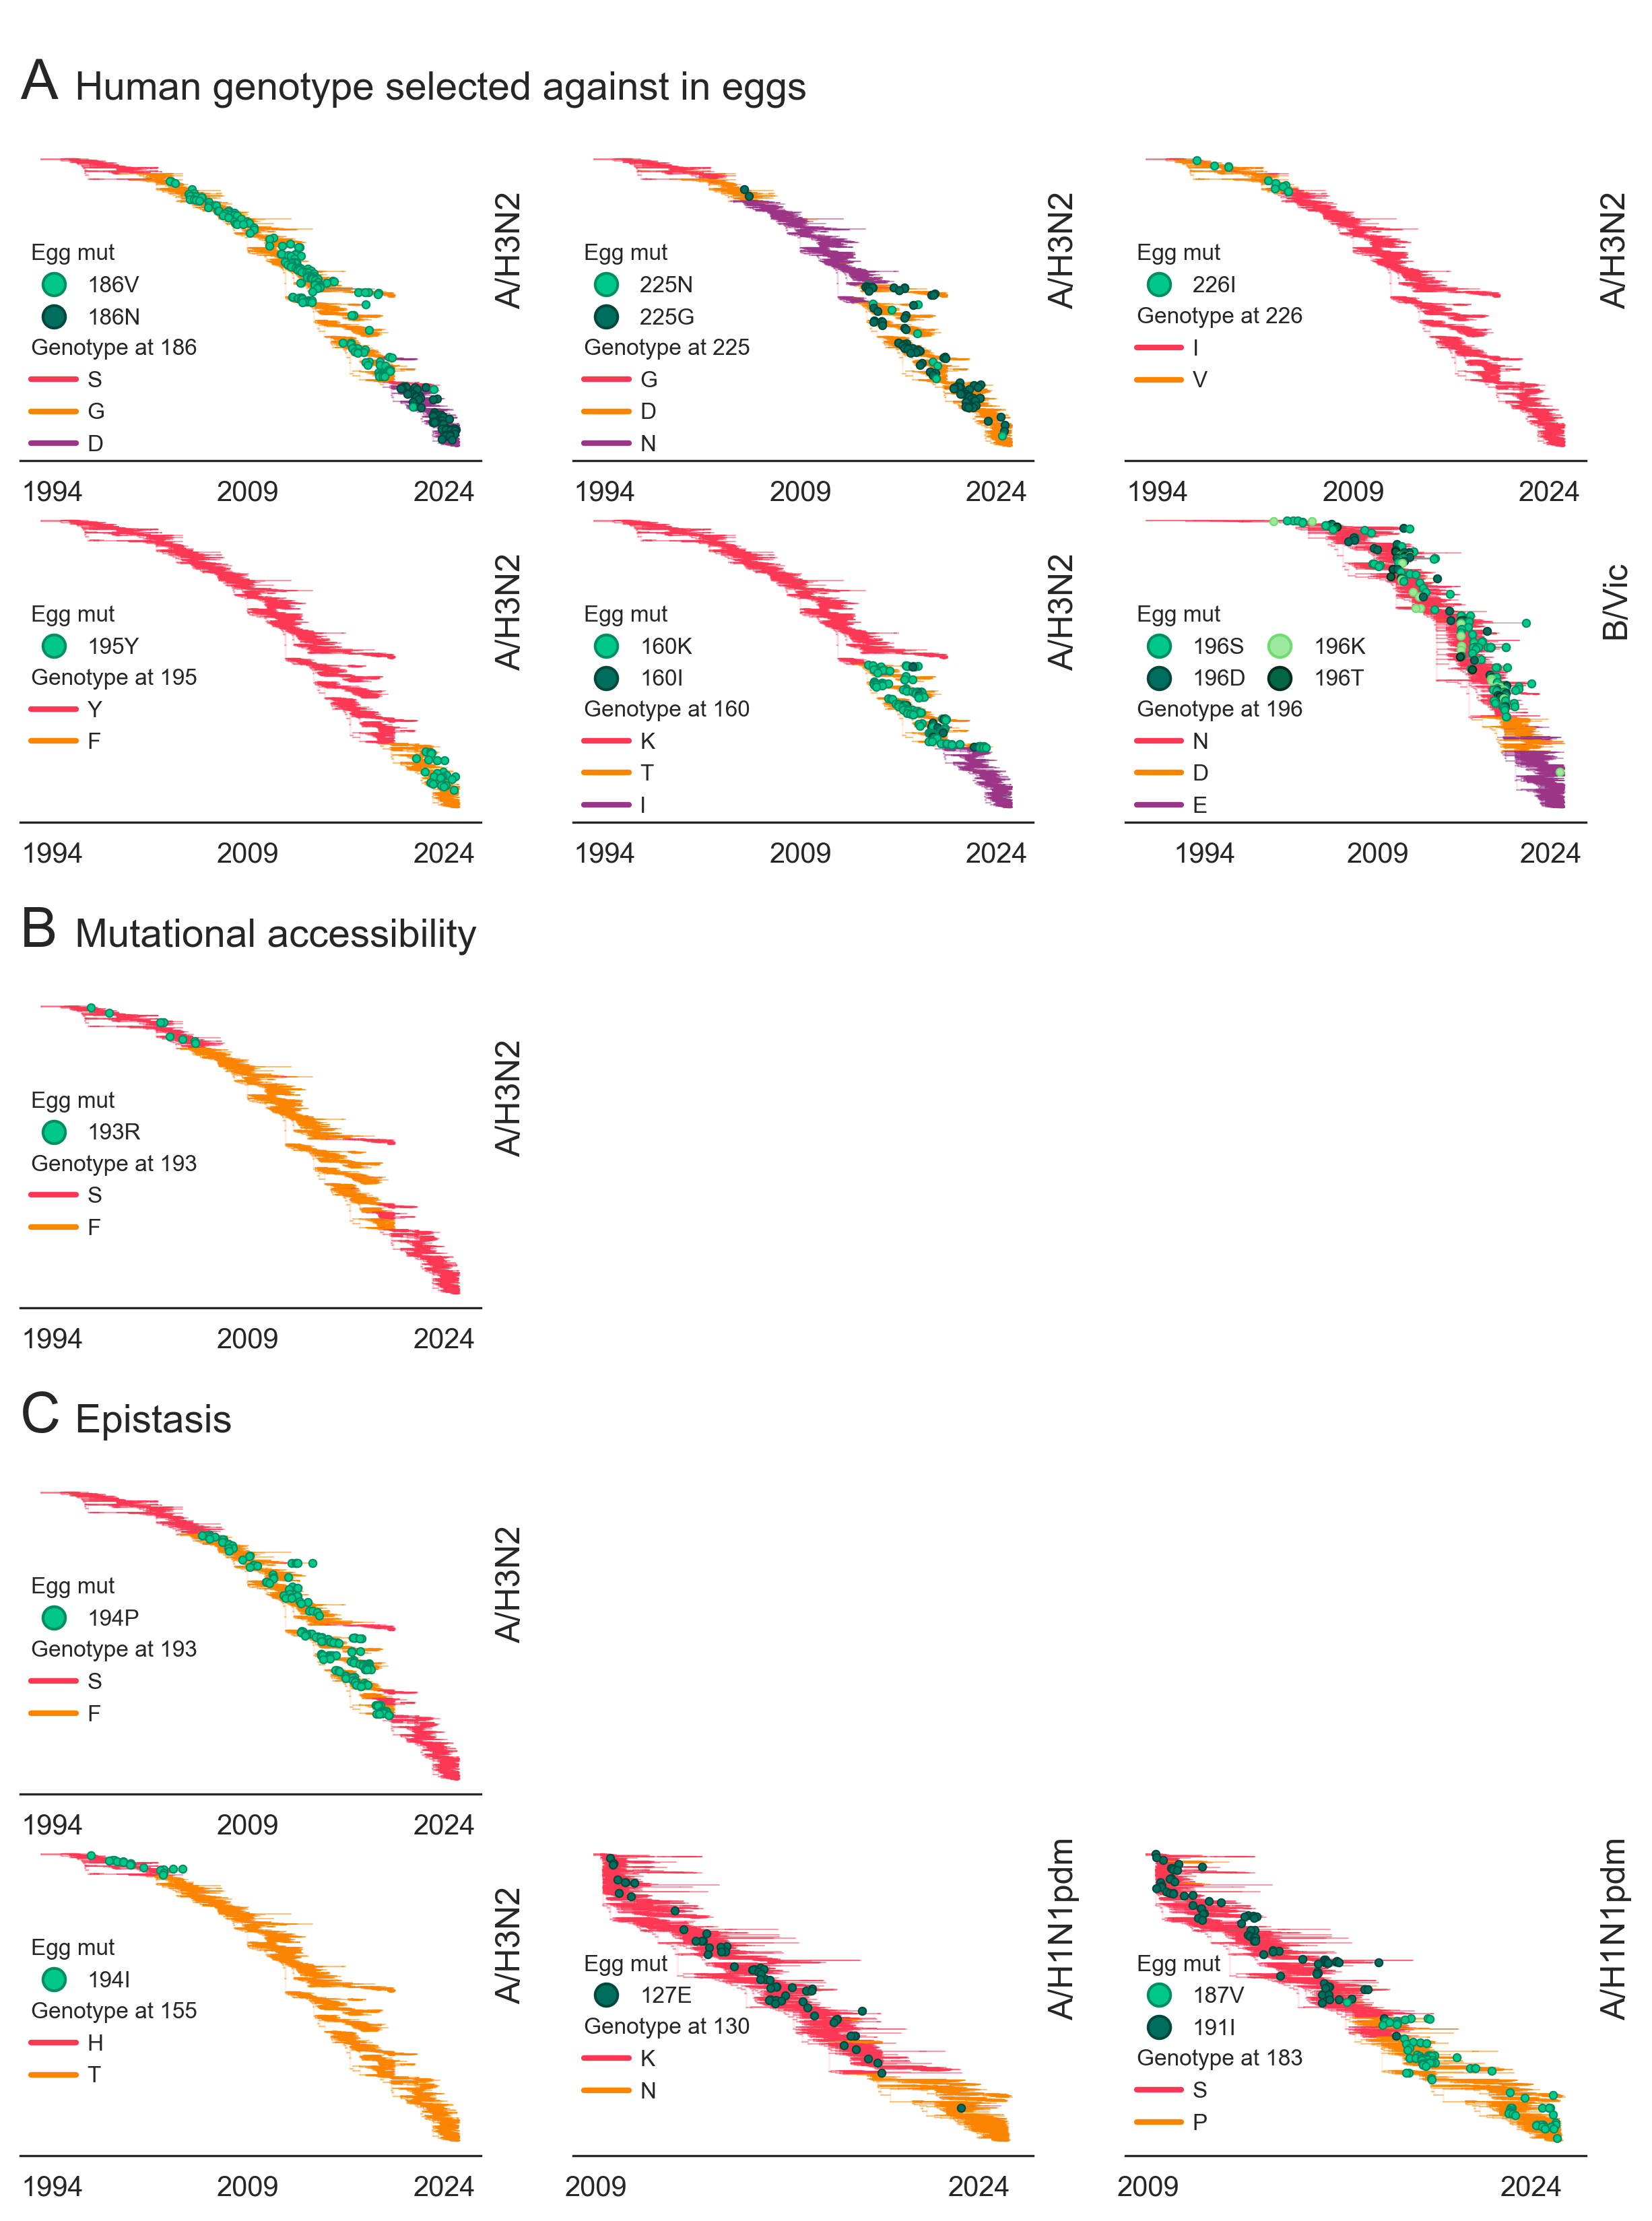

In [17]:
plot_fig4('Figure4/Figure4.png')